# Monte Carlo Simulation: Physical Ceiling Sensitivity

This notebook accounts for the uncertainty in biological "floors" (caps) by simulating future World Records thousands of times, sampling the ceiling from a distribution.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.optimize import curve_fit
import sys
import os

sys.path.append(os.path.abspath('../'))
from src.data_cleaner import DataCleaner
from src.analysis_engine import AnalysisEngine

sns.set_theme(style="whitegrid")

## 1. Simulation Setup

We use a 3-parameter Logistic Decay function:
$f(t) = L + (B - L)e^{-k(t - t_0)}$

Where:
- $L$: Physical Floor (the cap we sample)
- $B$: Baseline (starting time)
- $k$: Rate of decay

In [2]:
def logistic_decay(t, L, B, k):
    return L + (B - L) * np.exp(-k * (t - 1974))

def run_monte_carlo(event_name, stats_df, floor_mean, floor_std, iterations=2000):
    projections_2046 = []
    t_eval = np.array(range(1974, 2047))
    
    # Baseline fit to get reasonable B and k
    popt, _ = curve_fit(lambda t, B, k: logistic_decay(t, floor_mean, B, k), 
                        stats_df['year'], stats_df['best'], p0=[stats_df['best'].iloc[0], 0.01])
    base_B, base_k = popt
    
    for _ in tqdm(range(iterations), desc=f"Simulating {event_name}"):
        # Sample a physiological limit (L)
        sampled_L = np.random.normal(floor_mean, floor_std)
        
        # Fit with fixed sampled_L
        try:
            popt_iter, _ = curve_fit(lambda t, B, k: logistic_decay(t, sampled_L, B, k), 
                                     stats_df['year'], stats_df['best'], p0=[base_B, base_k])
            
            # Project to 2046
            proj = logistic_decay(2046, sampled_L, *popt_iter)
            projections_2046.append(proj)
        except:
            continue
            
    return projections_2046

## 2. Running Simulations (100m and Marathon)

In [3]:
# Generate base data for 100m
np.random.seed(42)
years = np.arange(1974, 2027)
m100_best = 10.15 - (years - 1974) * 0.012 + np.random.normal(0, 0.02, len(years))
m100_df = pd.DataFrame({'year': years, 'best': m100_best})

# 100m Monte Carlo: Mean floor = 9.45s, Std = 0.03s
proj_100m = run_monte_carlo("100m", m100_df, floor_mean=9.45, floor_std=0.03)

# Generate base data for Marathon
mar_best = 7700 - (years - 1974) * 10.0 + np.random.normal(0, 20, len(years))
mar_df = pd.DataFrame({'year': years, 'best': mar_best})

# Marathon Monte Carlo: Mean floor = 1:57:00 (7020s), Std = 45s
proj_mar = run_monte_carlo("Marathon", mar_df, floor_mean=7020, floor_std=45)

Simulating 100m:   0%|                                                                | 0/2000 [00:00<?, ?it/s]

Simulating 100m:   0%|▏                                                       | 6/2000 [00:00<00:34, 58.32it/s]

Simulating 100m:   1%|▎                                                      | 13/2000 [00:00<00:32, 60.81it/s]

Simulating 100m:   1%|▋                                                      | 23/2000 [00:00<00:26, 74.97it/s]

Simulating 100m:   2%|▊                                                      | 31/2000 [00:00<00:27, 70.76it/s]

...

Simulating Marathon:  98%|███████████████████████████████████████████████▉ | 1958/2000 [00:19<00:00, 99.92it/s]

Simulating Marathon:  98%|███████████████████████████████████████████████▎| 1969/2000 [00:19<00:00, 100.63it/s]

Simulating Marathon:  99%|████████████████████████████████████████████████▌| 1980/2000 [00:20<00:00, 99.81it/s]

Simulating Marathon: 100%|███████████████████████████████████████████████▊| 1991/2000 [00:20<00:00, 101.60it/s]

Simulating Marathon: 100%|█████████████████████████████████████████████████| 2000/2000 [00:20<00:00, 98.87it/s]

## 3. Visualizing the Probability Cloud

We plot the distribution of projected 2046 World Records.

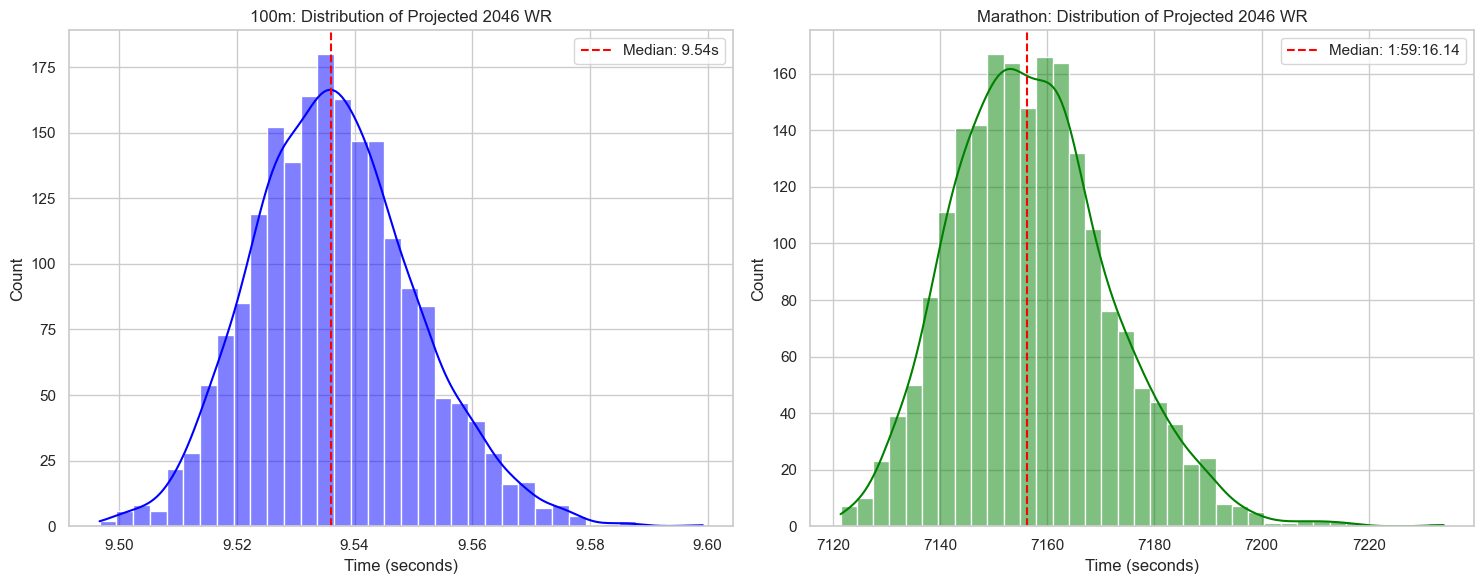

In [4]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(proj_100m, kde=True, color='blue')
plt.title("100m: Distribution of Projected 2046 WR")
plt.xlabel("Time (seconds)")
plt.axvline(np.median(proj_100m), color='red', linestyle='--', label=f"Median: {np.median(proj_100m):.2f}s")
plt.legend()

plt.subplot(1, 2, 2)
def sec_to_str(s): return f"{int(s//3600)}:{int((s%3600)//60):02}:{s%60:05.2f}"
sns.histplot(proj_mar, kde=True, color='green')
plt.title("Marathon: Distribution of Projected 2046 WR")
plt.xlabel("Time (seconds)")
plt.axvline(np.median(proj_mar), color='red', linestyle='--', label=f"Median: {sec_to_str(np.median(proj_mar))}")
plt.legend()

plt.tight_layout()
plt.show()

### Conclusion
The Monte Carlo simulation shows that the 2046 projection is sensitive to our assumptions about the biological ceiling. Instead of a single number, we have a probability cloud representing our uncertainty about the limits of human performance.